## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project predicts the selling price of used cars based on specifications such as manufacturing year, showroom price, kilometers driven, fuel type, seller type, transmission, and owner history.


### 2) Data Collection
- **Dataset Overview**:
- **Records**: 301 vehicle entries
- **Target Variable**: `Selling_Price` (in Lakhs)
- **Primary Features**: `Present_Price`, `Kms_Driven`, `Fuel_Type`, `Seller_Type`, `Transmission`, `Owner`, and calculated `Car_Age`.
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [35]:
df = pd.read_csv('data/car_data.csv')

#### Show Top 5 Records

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


#### Shape of the dataset

In [36]:
df.shape

(301, 9)

### 2.2 Dataset information

- ### 2.2 Dataset information

- **Car_Name**: Name of the car
- **Year**: Manufacturing year of the car
- **Selling_Price**: Price at which the car is being sold (in Lakhs) — **Target Variable**
- **Present_Price**: Current showroom price of the car (in Lakhs)
- **Kms_Driven**: Total distance driven by the car in kilometers
- **Fuel_Type**: Fuel type of the car (Petrol / Diesel / CNG)
- **Seller_Type**: Type of seller selling the car (Dealer / Individual)
- **Transmission**: Transmission system of the car (Manual / Automatic)
- **Owner**: Number of previous owners (0, 1, or 3+)

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [5]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [6]:
df.duplicated().sum()

np.int64(2)

#### There are no duplicates  values in the data set

### 3.3 Check data types

In [7]:
# Check Null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


### 3.4 Checking the number of unique values of each column

In [8]:
df.nunique()

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64

### 3.5 Check statistics of data set

In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.7 Exploring Data

In [10]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [11]:
print("Categories in 'Fuel_Type' variable:    ", end=" ")
print(df['Fuel_Type'].unique())

print("Categories in 'Seller_Type' variable:  ", end=" ")
print(df['Seller_Type'].unique())

print("Categories in 'Transmission' variable: ", end=" ")
print(df['Transmission'].unique())

print("Categories in 'Owner' variable:        ", end=" ")
print(df['Owner'].unique())

Categories in 'Fuel_Type' variable:     <ArrowStringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
Categories in 'Seller_Type' variable:   <ArrowStringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Categories in 'Transmission' variable:  <ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
Categories in 'Owner' variable:         [0 1 3]


We have **6 numerical features**:
- `Year` (Manufacturing year)
- `Car_Age` (Engineered: 2026 - Year)
- `Selling_Price` (Target variable, in Lakhs)
- `Present_Price` (Current showroom price, in Lakhs)
- `Price_Difference` (Engineered: Present_Price - Selling_Price)
- `Kms_Driven` (Total kilometers driven)
- `Owner` (Number of previous owners: 0, 1, 3)

We have **4 categorical features**:
- `Car_Name` (Vehicle model name)
- `Fuel_Type` (Petrol, Diesel, CNG)
- `Seller_Type` (Dealer, Individual)
- `Transmission` (Manual, Automatic)

In [12]:
df.head(2)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0


#### 3.8 FEATURE ENGINEERING: CALCULATING CAR AGE
- Derive the continuous feature `Car_Age` by subtracting the manufacturing year from the current year (2026).
- Transform static calendar metadata into an actionable operational variable for depreciation analysis.

In [13]:
df['Car_Age'] = 2026 - df['Year']
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [14]:
first_owner_cars = df[df['Owner'] == 0]['Selling_Price'].count()
automatic_cars = df[df['Transmission'] == 'Automatic']['Selling_Price'].count()
diesel_cars = df[df['Fuel_Type'] == 'Diesel']['Selling_Price'].count()

print(f'Number of First-Owner Cars: {first_owner_cars}')
print(f'Number of Automatic Transmission Cars: {automatic_cars}')
print(f'Number of Diesel Fuel Cars: {diesel_cars}')

Number of First-Owner Cars: 290
Number of Automatic Transmission Cars: 40
Number of Diesel Fuel Cars: 60


In [15]:
low_price_cars = df[df['Selling_Price'] <= 1]['Selling_Price'].count()
high_kms_cars = df[df['Kms_Driven'] >= 100000]['Selling_Price'].count()
old_cars = df[df['Car_Age'] >= 10]['Selling_Price'].count()

print(f'Number of cars with Selling Price <= 1 Lakh: {low_price_cars}')
print(f'Number of cars driven >= 100,000 kms: {high_kms_cars}')
print(f'Number of cars 10 years or older: {old_cars}')

Number of cars with Selling Price <= 1 Lakh: 79
Number of cars driven >= 100,000 kms: 8
Number of cars 10 years or older: 265


#####  Insights
Low Budget Segment: Analyzed the proportion of budget cars priced at or below 1 Lakh to evaluate lower-bound target variable distribution.

Usage & Mileage Exposure: Identified high-mileage vehicles (driven over 100,000 km) that typically exhibit higher depreciation rates.

Depreciation & Age Distribution: Segmented vehicles aged 10 years or older to assess the impact of vehicle age on resale price decay.

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

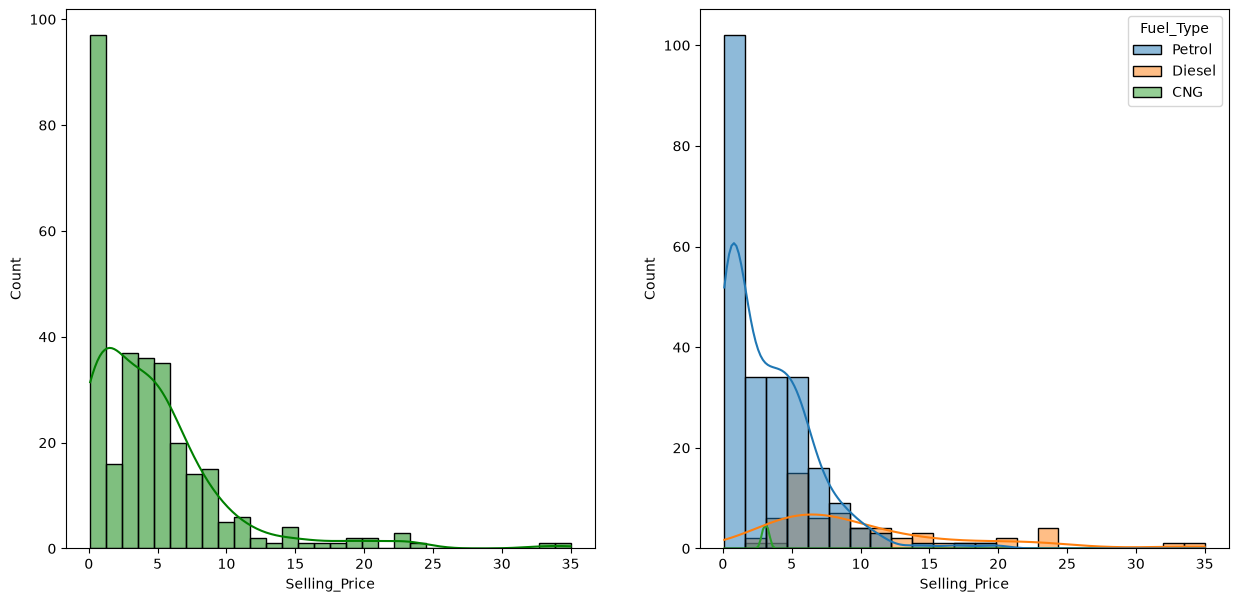

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='Selling_Price', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='Selling_Price', kde=True, hue='Fuel_Type')
plt.show()

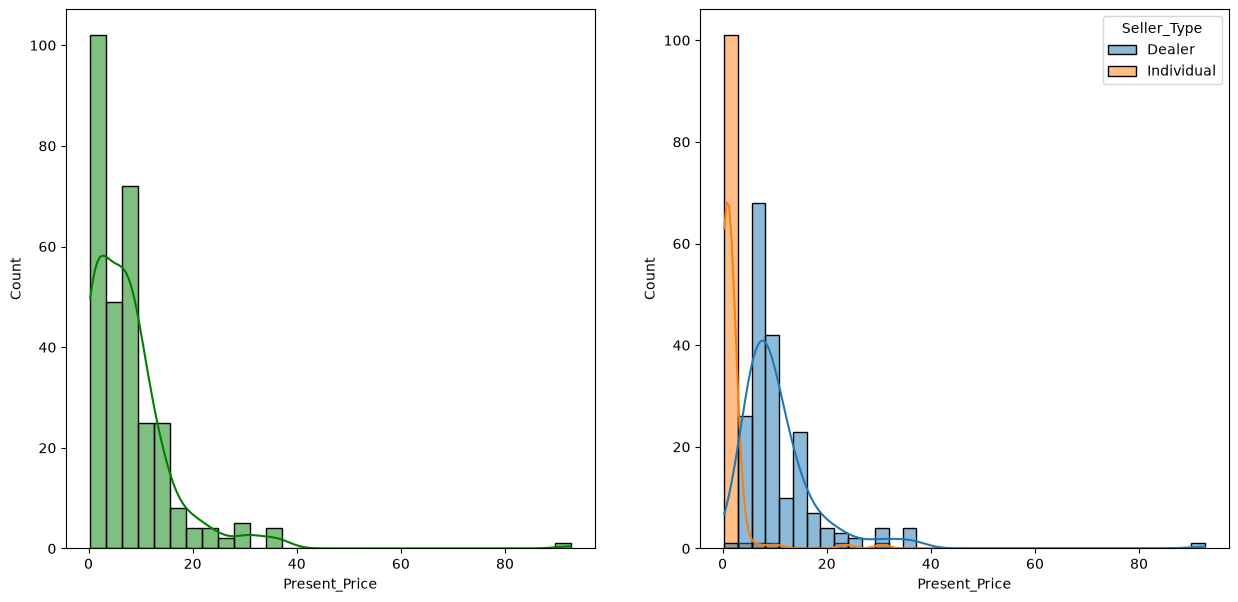

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='Present_Price', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='Present_Price', kde=True, hue='Seller_Type')
plt.show()

#####  Insights
Showroom Price Distribution: Present_Price exhibits a right-skewed distribution, showing that most vehicles in the dataset originally belonged to the economy or mid-range price segment.

Seller Channel Segmentation: Vehicles sold by Dealers generally cover a wider and higher range of showroom prices (Present_Price) compared to those listed directly by Individual sellers.

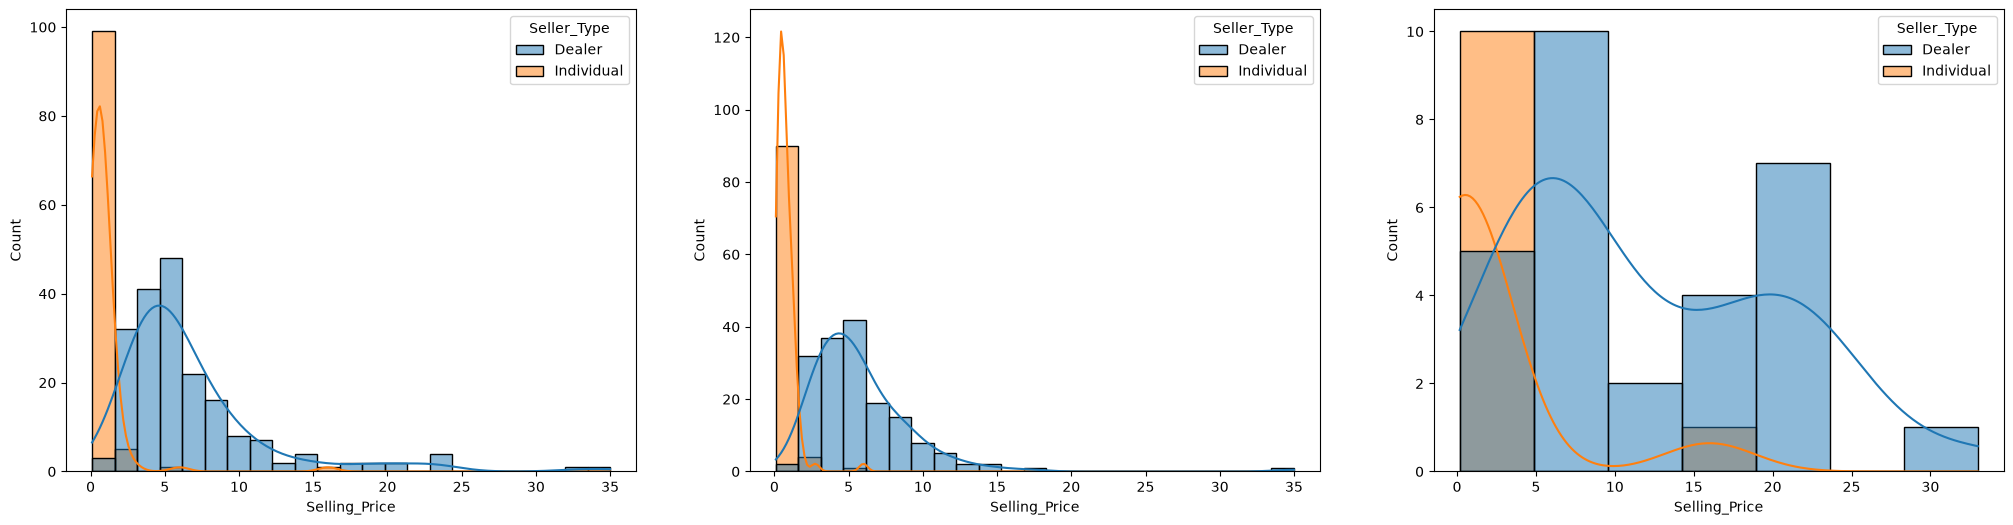

In [18]:
plt.subplots(1, 3, figsize=(25, 6))
plt.subplot(131)
sns.histplot(data=df, x='Selling_Price', kde=True, hue='Seller_Type')
plt.subplot(132)
sns.histplot(data=df[df.Transmission == 'Manual'], x='Selling_Price', kde=True, hue='Seller_Type')
plt.subplot(133)
sns.histplot(data=df[df.Transmission == 'Automatic'], x='Selling_Price', kde=True, hue='Seller_Type')
plt.show()

#####  Insights
Dealer Dominance: Dealer listings capture higher overall selling prices compared to Individual sellers across both transmission types.

Transmission Segmentation: Automatic vehicles are clustered at higher price points, whereas Manual vehicles represent the vast majority of lower to mid-range sales.

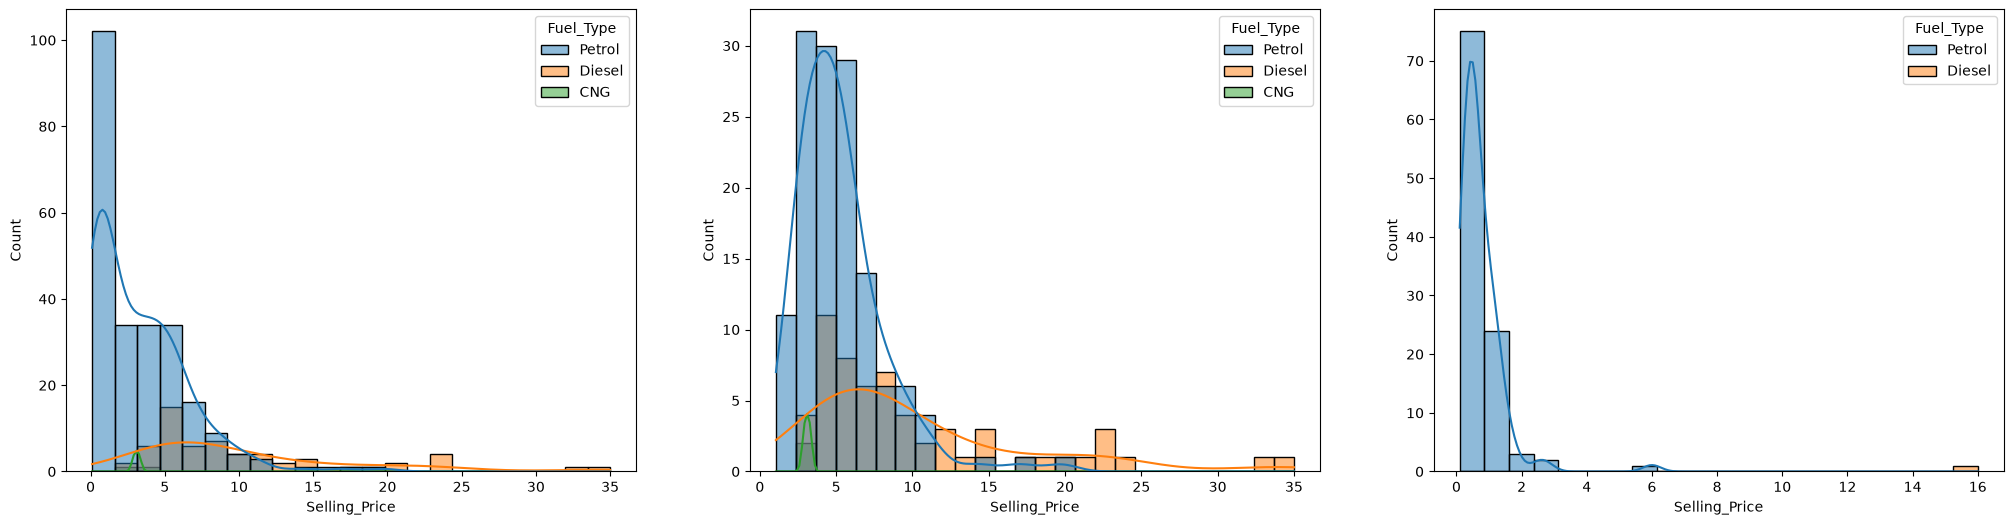

In [19]:
plt.subplots(1, 3, figsize=(25, 6))
plt.subplot(131)
ax = sns.histplot(data=df, x='Selling_Price', kde=True, hue='Fuel_Type')
plt.subplot(132)
ax = sns.histplot(data=df[df.Seller_Type == 'Dealer'], x='Selling_Price', kde=True, hue='Fuel_Type')
plt.subplot(133)
ax = sns.histplot(data=df[df.Seller_Type == 'Individual'], x='Selling_Price', kde=True, hue='Fuel_Type')
plt.show()

#####  Insights
Fuel Preference by Seller: Dealer listings feature a mix of Diesel and Petrol vehicles spanning broader price ranges, whereas Individual seller listings are heavily dominated by Petrol cars concentrated at lower price points.

Diesel Price Premium: Diesel vehicles consistently occupy higher price tiers across both Dealer and Individual sales channels.

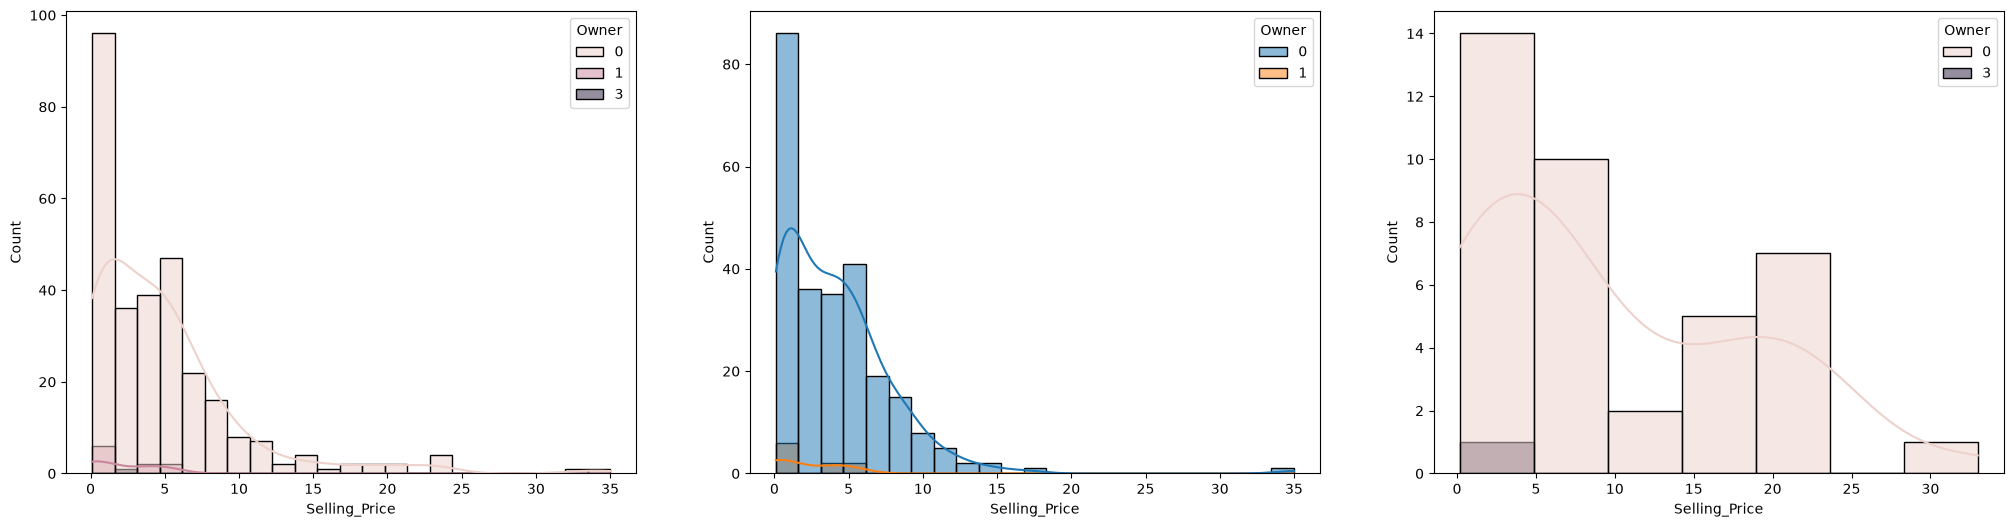

In [20]:
plt.subplots(1, 3, figsize=(25, 6))
plt.subplot(131)
ax = sns.histplot(data=df, x='Selling_Price', kde=True, hue='Owner')
plt.subplot(132)
ax = sns.histplot(data=df[df.Transmission == 'Manual'], x='Selling_Price', kde=True, hue='Owner')
plt.subplot(133)
ax = sns.histplot(data=df[df.Transmission == 'Automatic'], x='Selling_Price', kde=True, hue='Owner')
plt.show()

#####  Insights
Ownership Impact on Resale Value: First-owner cars (Owner == 0) comprise the overwhelming majority of the dataset and command significantly higher resale values compared to second-hand or third-hand vehicles.

Transmission Preference: First-owner vehicles dominate both Manual and Automatic categories, but second and third-owner vehicles appear almost exclusively in the lower-priced Manual market segment.

#### 4.2 CONTINUOUS FEATURE DISTRIBUTIONS (VIOLINPLOTS)
- Evaluate probability density, median spread, and extreme values across `Selling_Price`, `Present_Price`, and `Kms_Driven`.

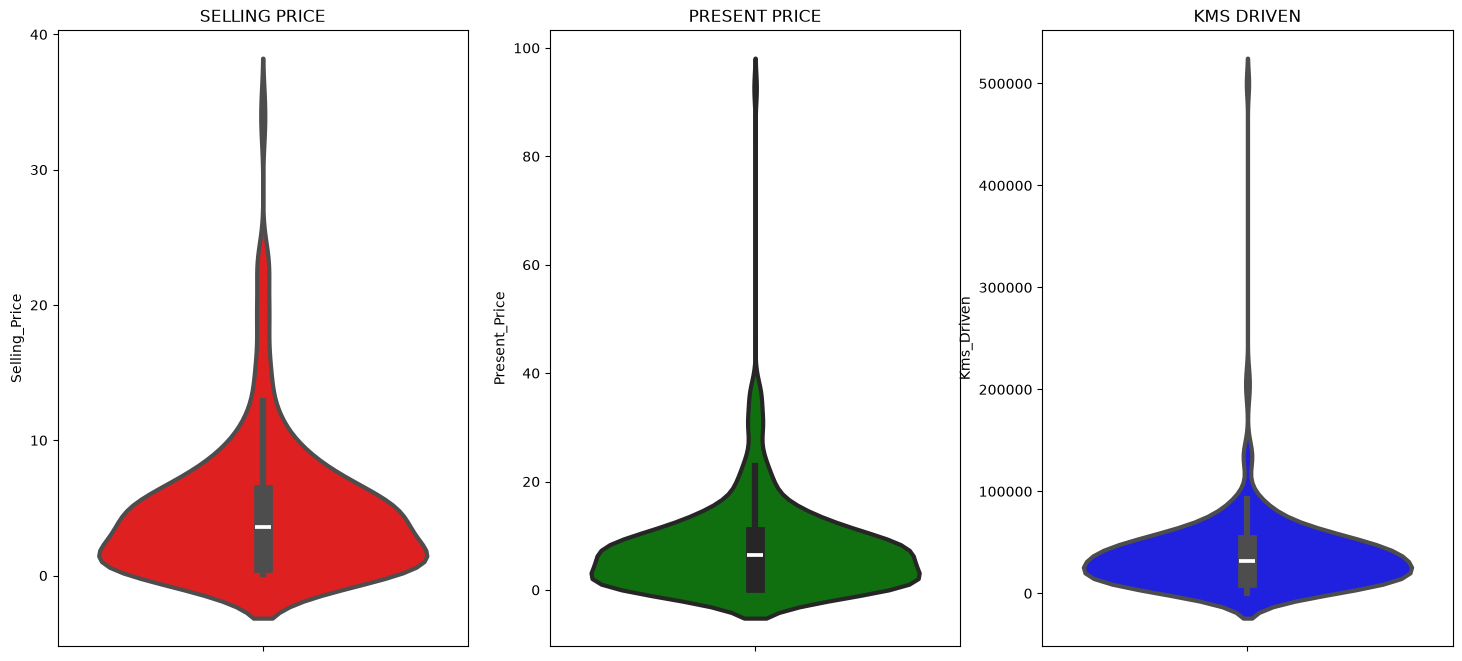

In [21]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 3, 1)
plt.title('SELLING PRICE')
sns.violinplot(y='Selling_Price', data=df, color='red', linewidth=3)

plt.subplot(1, 3, 2)
plt.title('PRESENT PRICE')
sns.violinplot(y='Present_Price', data=df, color='green', linewidth=3)

plt.subplot(1, 3, 3)
plt.title('KMS DRIVEN')
sns.violinplot(y='Kms_Driven', data=df, color='blue', linewidth=3)

plt.show()

#### Insights
Value Concentration: Both Selling_Price and Present_Price show narrow, heavy bases near lower values, reflecting a market dominated by affordable budget cars with a long tail of high-value outliers.

Usage Skew: Kms_Driven demonstrates a similar right-skewed distribution, showing that most listed cars have moderate mileage under 100,000 km, with few highly driven vehicles.

#### 4.3 Multivariate analysis using pieplot

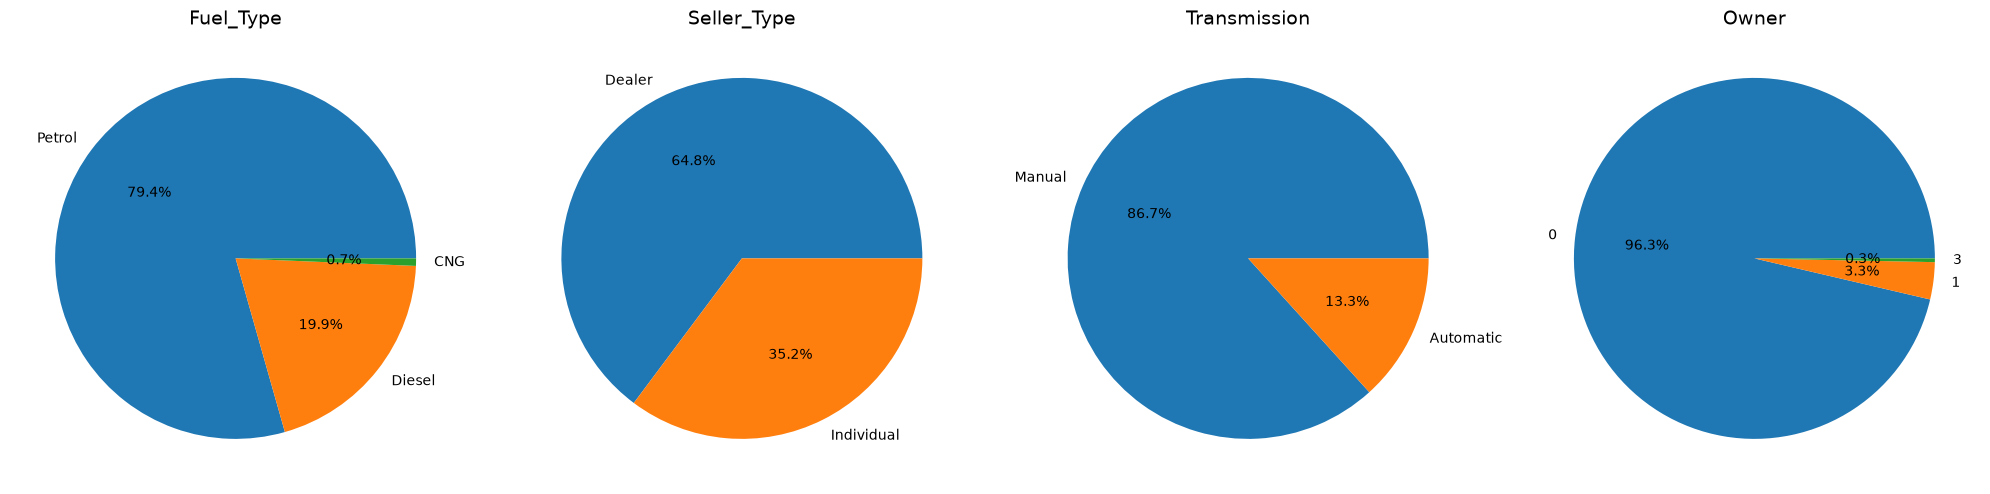

In [22]:
plt.rcParams['figure.figsize'] = (20, 5)
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 4, i)
    counts = df[col].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%.1f%%')
    plt.title(col, fontsize=14)

plt.tight_layout()
plt.show()

#####  Insights
Fuel Dominance: Petrol and Diesel cars constitute the vast majority of listings, while CNG vehicles represent a minor fraction of the dataset.

Primary Sales Channel: Dealer listings make up the main share of sales over direct Individual seller listings.

Transmission Preference: Manual transmission vehicles dominate the overall inventory compared to Automatic models.

Ownership Profile: First-owner vehicles (0) make up almost the entire sample, with very few second-owner (1) or third-owner (3) listings.

#### 4.4 Feature Wise Visualization
#### 4.4.1 FUEL TYPE COLUMN
- How is the distribution of Fuel Type across the dataset?
- Does Fuel Type have an impact on a car's selling price?

#### UNIVARIATE ANALYSIS (Distribution of Fuel Type)

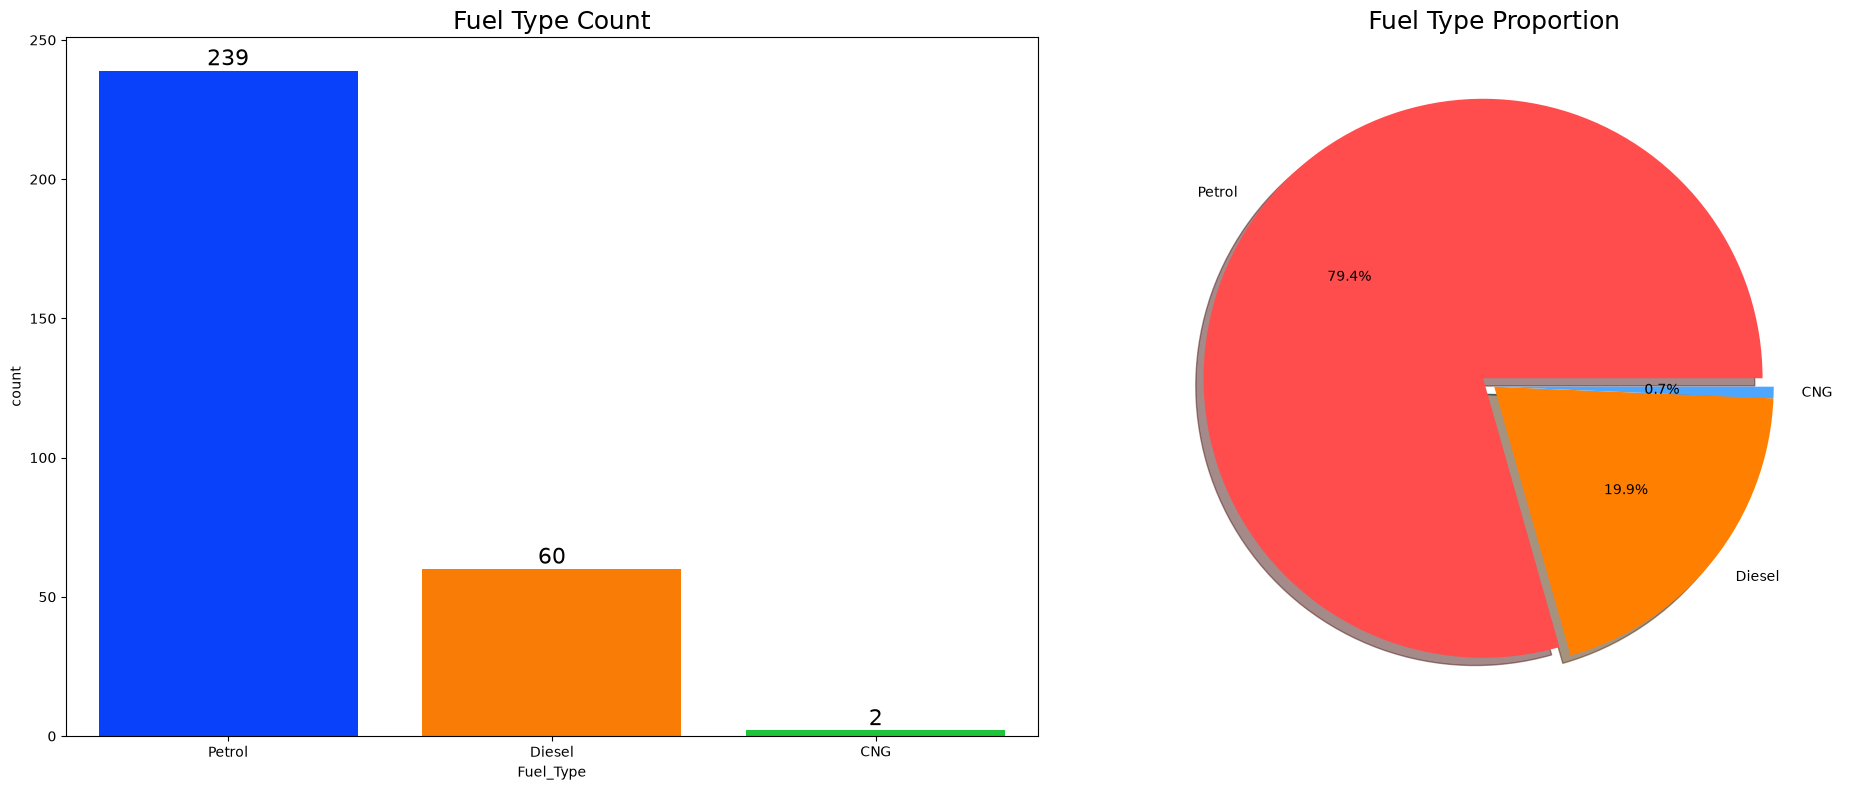

In [23]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

# Countplot with bar labels
sns.countplot(x=df['Fuel_Type'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=16)
ax[0].set_title('Fuel Type Count', fontsize=18)

# Pie chart using dynamic category indexes
counts = df['Fuel_Type'].value_counts()
ax[1].pie(x=counts, labels=counts.index, autopct='%1.1f%%', shadow=True, 
           colors=['#ff4d4d', '#ff8000', '#4da6ff'], explode=[0.05 if i == 0 else 0 for i in range(len(counts))])
ax[1].set_title('Fuel Type Proportion', fontsize=18)

plt.tight_layout()
plt.show()

#### Insights 
Dominant Fuel Choice: Petrol vehicles constitute the largest share of the dataset (~79.4%), followed by Diesel vehicles (~19.9%).

Minority Segment: CNG vehicles represent a negligible fraction (< 1%) of the total inventory.

#### BIVARIATE ANALYSIS (Impact of Fuel Type on Resale Value & Original Price)

In [24]:
fuel_group = df.groupby('Fuel_Type')[['Selling_Price', 'Present_Price', 'Kms_Driven', 'Car_Age']].mean()
fuel_group

,Selling_Price,Present_Price,Kms_Driven,Car_Age
Fuel_Type,,,,
CNG,3.100000,6.415000,42749.000000,13.000000
Diesel,10.278500,15.814500,50369.916667,12.000000
Petrol,3.264184,5.583556,33528.937238,12.460251


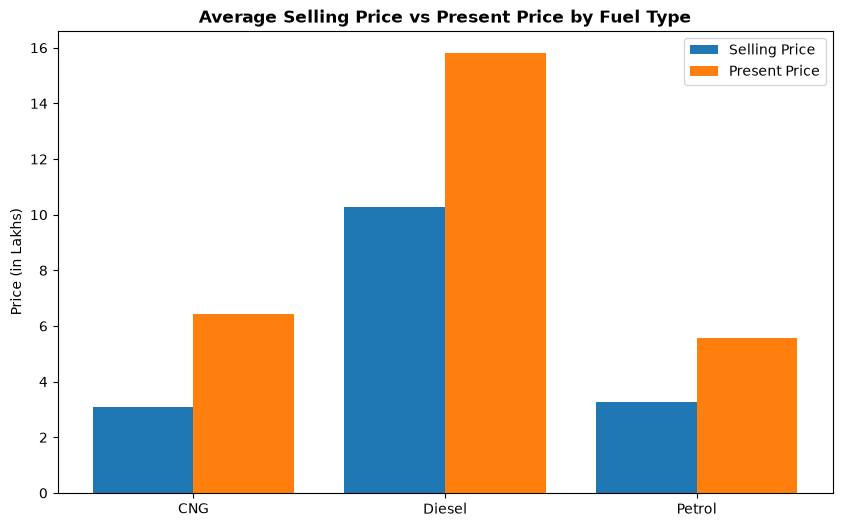

In [25]:
plt.figure(figsize=(10, 6))

X = fuel_group.index
X_axis = np.arange(len(X))

selling_prices = fuel_group['Selling_Price']
present_prices = fuel_group['Present_Price']

plt.bar(X_axis - 0.2, selling_prices, 0.4, label='Selling Price')
plt.bar(X_axis + 0.2, present_prices, 0.4, label='Present Price')

plt.xticks(X_axis, X)
plt.ylabel("Price (in Lakhs)")
plt.title("Average Selling Price vs Present Price by Fuel Type", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
Market Valuation: Diesel cars retain higher resale value relative to their original cost compared to Petrol and CNG vehicles.

Depreciation Gap: The gap between Present_Price and Selling_Price visually quantifies the average value lost to depreciation across each fuel segment.

#### 4.4.3 TRANSMISSION COLUMN
- What is the distribution of Transmission types across the dataset?
- Does Transmission type have an impact on a car's selling price?

#### UNIVARIATE ANALYSIS (Distribution of Seller Type)

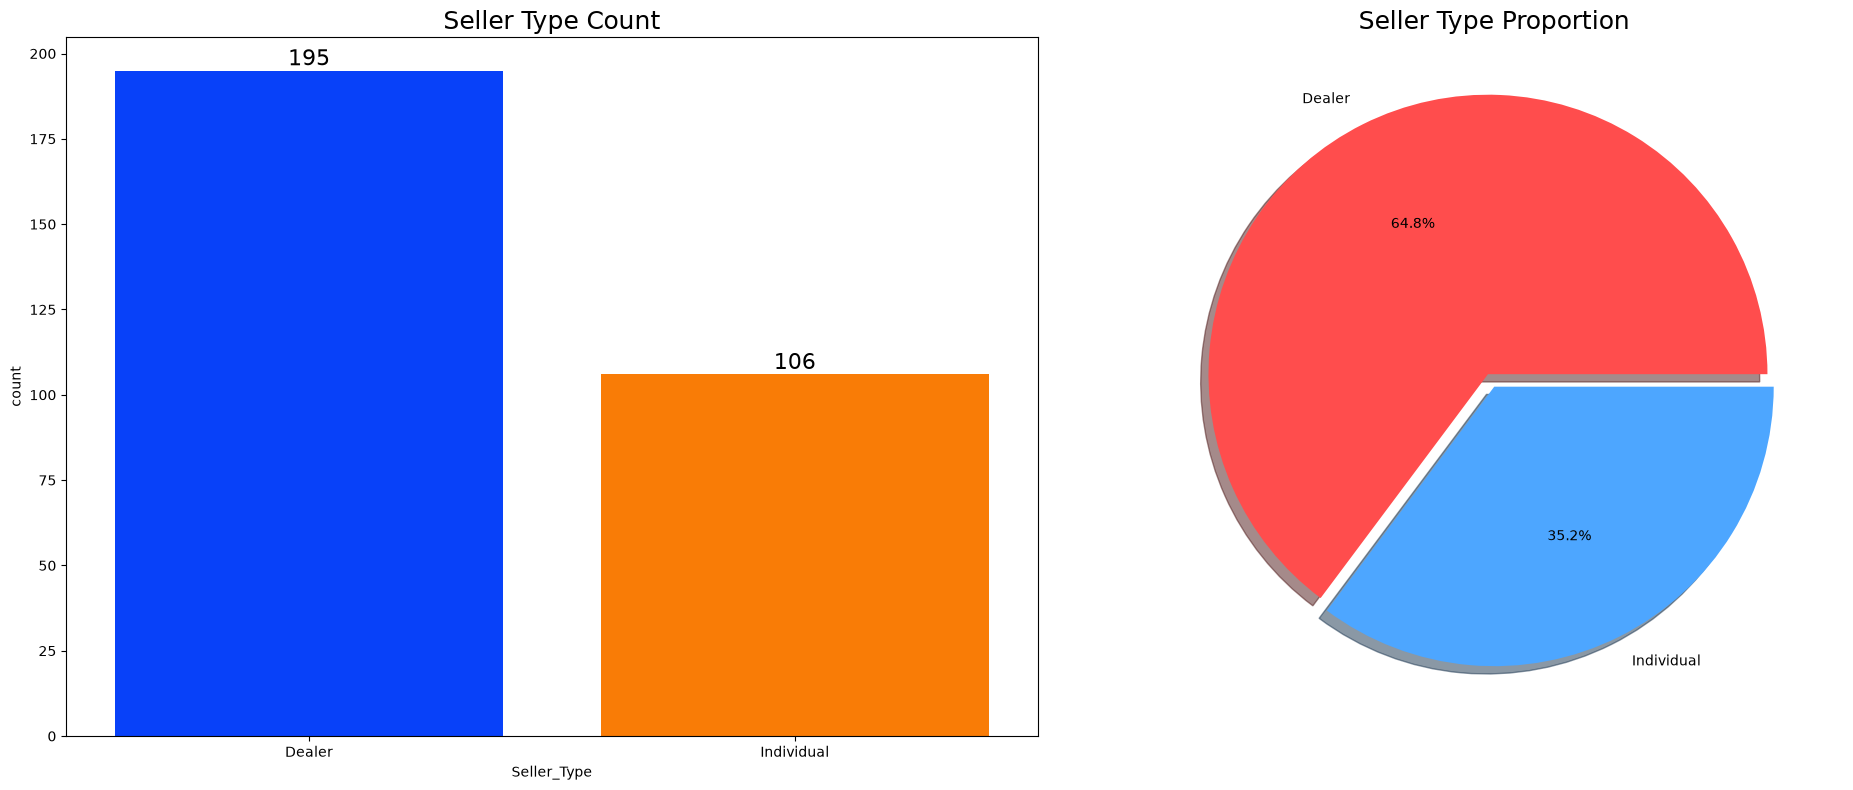

In [26]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

# Countplot with bar labels
sns.countplot(x=df['Seller_Type'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=16)
ax[0].set_title('Seller Type Count', fontsize=18)

# Pie chart using dynamic category indexes
counts = df['Seller_Type'].value_counts()
ax[1].pie(x=counts, labels=counts.index, autopct='%1.1f%%', shadow=True, 
           colors=['#ff4d4d', '#4da6ff'], explode=[0.05, 0])
ax[1].set_title('Seller Type Proportion', fontsize=18)

plt.tight_layout()
plt.show()

#### Insights 
Market Share: Vehicles listed by Dealers account for nearly two-thirds (~64.8%) of the total inventory.

Direct Sales: Listings directly from Individual owners make up the remaining ~35.2% of the dataset.

#### BIVARIATE ANALYSIS (Impact of Seller Type on Resale Value & Original Price)

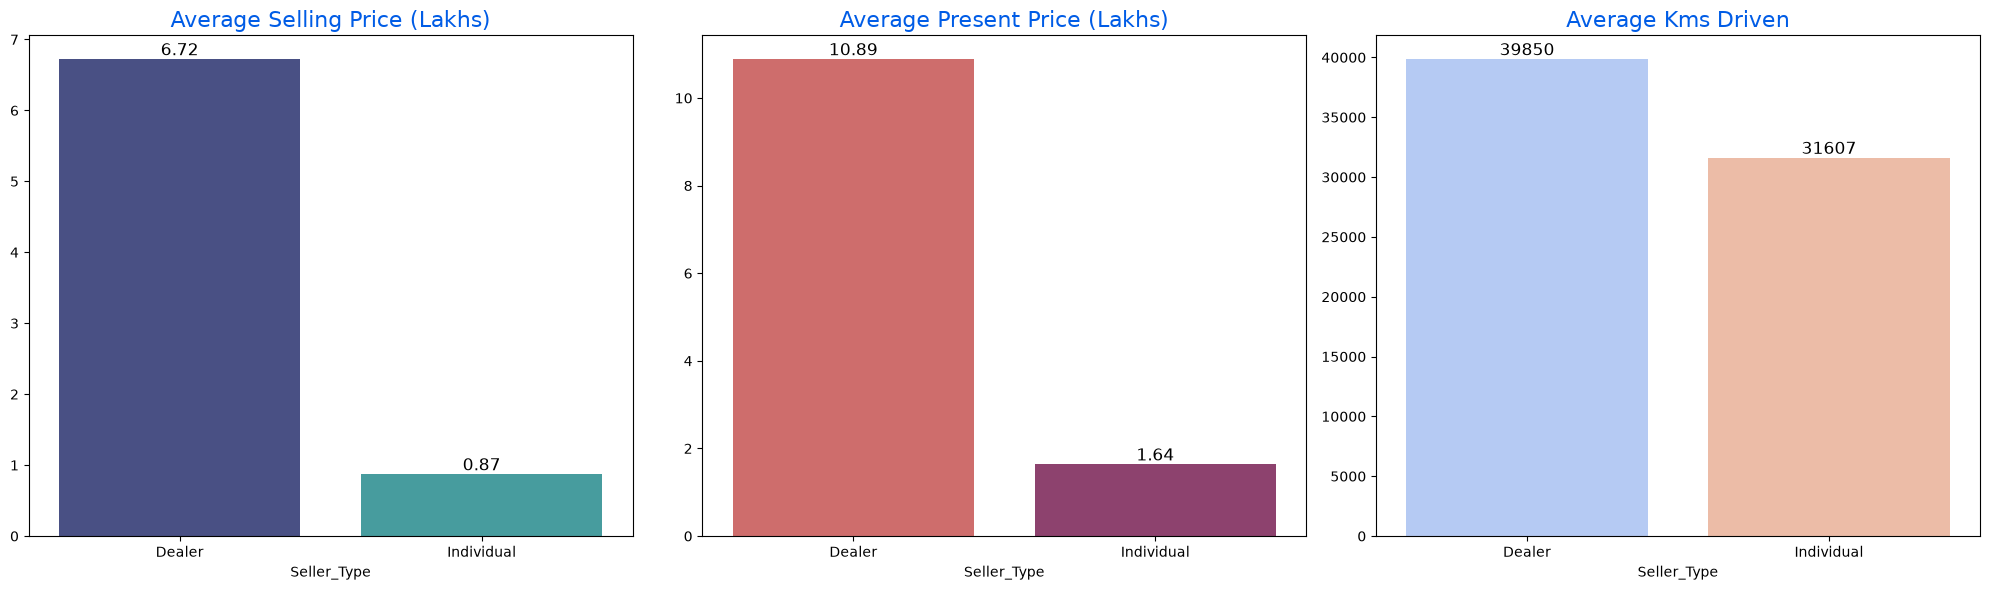

In [27]:
Group_data2 = df.groupby('Seller_Type')
f, ax = plt.subplots(1, 3, figsize=(20, 6))

# Subplot 1: Selling Price
sns.barplot(x=Group_data2['Selling_Price'].mean().index, y=Group_data2['Selling_Price'].mean().values, palette='mako', ax=ax[0])
ax[0].set_title('Average Selling Price (Lakhs)', color='#005ce6', size=16)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=12, fmt='%.2f')

# Subplot 2: Present Price
sns.barplot(x=Group_data2['Present_Price'].mean().index, y=Group_data2['Present_Price'].mean().values, palette='flare', ax=ax[1])
ax[1].set_title('Average Present Price (Lakhs)', color='#005ce6', size=16)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=12, fmt='%.2f')

# Subplot 3: Kms Driven
sns.barplot(x=Group_data2['Kms_Driven'].mean().index, y=Group_data2['Kms_Driven'].mean().values, palette='coolwarm', ax=ax[2])
ax[2].set_title('Average Kms Driven', color='#005ce6', size=16)
for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=12, fmt='%.0f')

plt.tight_layout()
plt.show()

#### Insights 
Valuation Advantage: Dealer listings feature significantly higher average original showroom prices (Present_Price) and command much higher average selling prices (Selling_Price).

Usage Patterns: Vehicles listed by Individual sellers generally have higher average mileage (Kms_Driven), which contributes to lower overall resale valuations.

#### 4.4.3 TRANSMISSION COLUMN
- What is the distribution of Transmission types across the dataset?
- Does Transmission type have an impact on a car's selling price?

#### UNIVARIATE ANALYSIS (Distribution of Transmission)

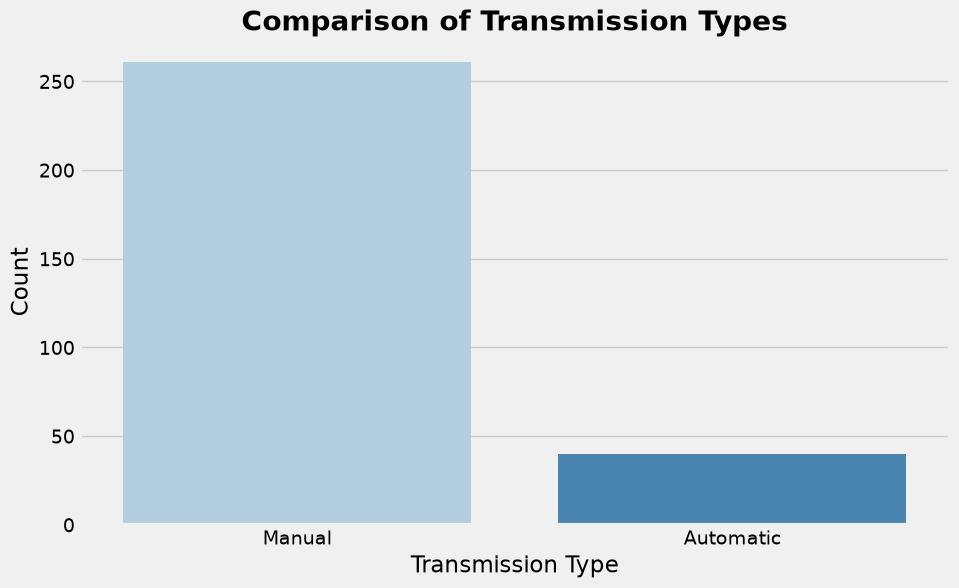

In [28]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('fivethirtyeight')

sns.countplot(data=df, x='Transmission', hue='Transmission', palette='Blues', legend=False)

# Changed fontweight=30 to fontweight='bold'
plt.title('Comparison of Transmission Types', fontweight='bold', fontsize=20)
plt.xlabel('Transmission Type')
plt.ylabel('Count')

plt.show()

#### Insights 
Market Dominance: Manual transmission vehicles heavily dominate the inventory over Automatic alternatives.

Sample Size: The dataset contains a much larger sample size for Manual cars, which provides higher statistical stability when modeling manual car prices compared to automatic ones.

#### BIVARIATE ANALYSIS (Impact of Transmission on Car Metrics)

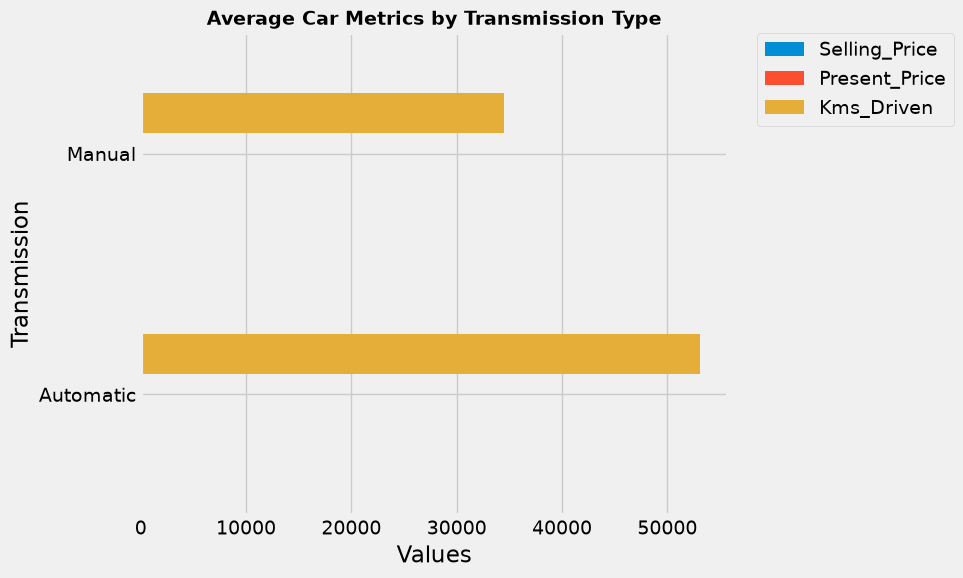

In [29]:
# Group by Transmission and calculate mean values
df.groupby('Transmission')[['Selling_Price', 'Present_Price', 'Kms_Driven']].mean().plot(kind='barh', figsize=(10, 6))

plt.title('Average Car Metrics by Transmission Type', fontweight='bold', fontsize=14)
plt.xlabel('Values')
plt.ylabel('Transmission')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.tight_layout()
plt.show()

#### Insights 
Premium Valuation: Automatic transmission cars exhibit substantially higher average showroom prices (Present_Price) and command higher resale prices (Selling_Price) than Manual cars.

Usage Comparison: Mileage levels (Kms_Driven) remain relatively comparable across both categories, confirming that the price differential is primarily driven by gear system configuration rather than vehicle usage.

#### 4.4.4 OWNER COLUMN
- Which owner type is most common among listed vehicles?
- Does the number of previous owners have an impact on a car's selling price?

#### UNIVARIATE ANALYSIS (Which owner type is most common among listed vehicles?)

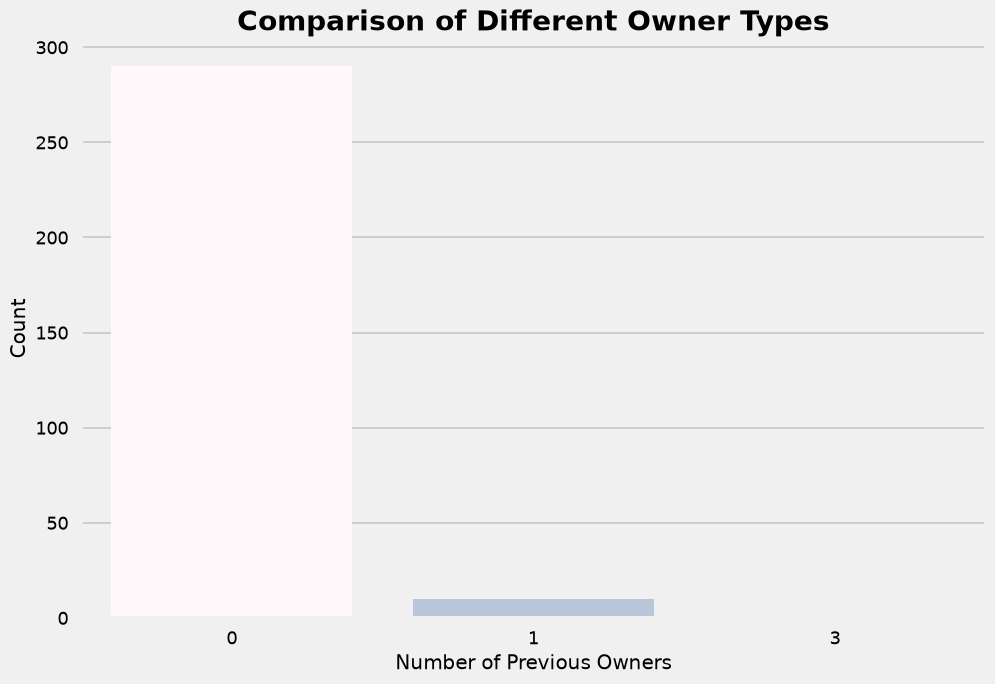

In [33]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-talk')

sns.countplot(data=df, x='Owner', hue='Owner', palette='PuBu', legend=False)

# Fixed fontweight=30 -> fontweight='bold'
plt.title('Comparison of Different Owner Types', fontweight='bold', fontsize=20)
plt.xlabel('Number of Previous Owners')
plt.ylabel('Count')

plt.show()

#### Insights 
Dominant Inventory: First-owner cars (Owner = 0) form the vast majority of all listings in the dataset.

Secondary Market: Second-owner (1) and higher-owner (3) vehicles represent a tiny fraction of total availability, indicating that multi-owner vehicles are rare in this dataset.

#### BIVARIATE ANALYSIS (Does vehicle ownership history impact pricing and fuel distribution?)

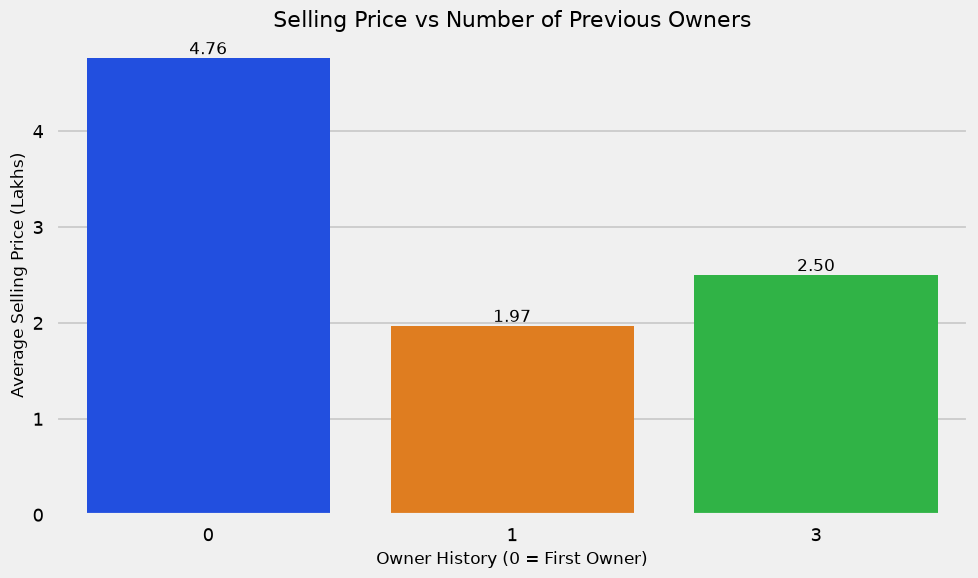

In [31]:
plt.figure(figsize=(10, 6))

# Added errorbar=None to remove the vertical black lines
ax = sns.barplot(
    x='Owner', 
    y='Selling_Price', 
    data=df, 
    hue='Owner', 
    palette='bright', 
    legend=False, 
    errorbar=None
)

plt.title('Selling Price vs Number of Previous Owners', color='black', size=16)
plt.xlabel('Owner History (0 = First Owner)', size=12)
plt.ylabel('Average Selling Price (Lakhs)', size=12)

for container in ax.containers:
    ax.bar_label(container, color='black', size=12, fmt='%.2f')

plt.tight_layout()
plt.show()

**Key Takeaway & Data Artifact**:
- **First-hand cars (`Owner = 0`)** command the highest average resale value (4.76 Lakhs).
- The apparent rise for `Owner = 3` (2.50 Lakhs) is a **sample size anomaly** caused by a single vehicle entry in the dataset, leading to zero variance (no error bar).

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x='Owner', data=df, hue='Fuel_Type', palette='bright')
plt.title('Vehicle Count by Owner History and Fuel Type', color='black', size=16)
plt.xlabel('Owner History', size=12)
plt.ylabel('Count', size=12)

for container in ax.containers:
    ax.bar_label(container, color='black', size=12)

plt.tight_layout()
plt.show()

#### Insights 
Valuation Depreciation: First-owner vehicles (0) command the highest average selling prices, whereas multi-owner vehicles experience steep value drop-offs due to perceived wear and accumulated mileage.

Inventory Distribution: Petrol and Diesel cars represent virtually the entirety of first-owner listings, with second and third-owner vehicles appearing in negligible counts across all fuel types.

In [ ]:
### 4.4.5 CORRELATION ANALYSIS & FEATURE SELECTION
- Evaluate pairwise linear relationships between numerical predictors and target (`Selling_Price`).

In [ ]:
plt.close('all')
plt.figure(figsize=(10, 6))

num_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
### 4.4.6 CATEGORICAL ENCODING (ONE-HOT ENCODING)
- Convert nominal variables (`Fuel_Type`, `Seller_Type`, `Transmission`) into binary indicators.
- Drop `Car_Name` due to high cardinality.

In [ ]:
# Create encoded dataframe while avoiding the dummy variable trap
df_encoded = pd.get_dummies(df.drop(columns=['Car_Name']), drop_first=True)
df_encoded.head()

#### 4.4.7 CAR AGE COLUMN
- How does the age of a car affect its resale value?
- Does vehicle age impact pricing differently across fuel types, transmission types, and seller types?

#### BIVARIATE ANALYSIS (Does vehicle age impact resale performance?)

In [ ]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x='Car_Age', y='Selling_Price', marker='o', color='#d95f02', linewidth=2.5)
plt.title('Selling Price Trajectory Over Vehicle Age', fontweight='bold', fontsize=14)
plt.xlabel('Car Age (Years)', fontsize=12)
plt.ylabel('Average Selling Price (Lakhs)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Insights  
Depreciation Curve: Selling_Price demonstrates a strong inverse relationship with Car_Age, declining rapidly within the first 3–5 years before stabilizing at lower price points for older models.

Feature Utility: Car_Age serves as a high-importance continuous predictor for the downstream regression models.

#### 4.4.8 CHECKING OUTLIERS
- Identify extreme values and skewness across continuous numerical features (`Selling_Price`, `Present_Price`, `Kms_Driven`).
- Evaluate potential data anomalies prior to model training.

In [ ]:
plt.close('all')
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Selling_Price'], color='skyblue')
plt.title('Outlier Check: Selling Price (in Lakhs)', fontweight='bold', fontsize=14)
plt.xlabel('Selling Price', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
plt.close('all')
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Present_Price'], color='hotpink')
plt.title('Outlier Check: Present Price (in Lakhs)', fontweight='bold', fontsize=14)
plt.xlabel('Present Price', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
plt.close('all')
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Kms_Driven'], color='yellow')
plt.title('Outlier Check: Kilometers Driven', fontweight='bold', fontsize=14)
plt.xlabel('Kms Driven', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
plt.close('all')
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Car_Age'], color='lightgreen')
plt.title('Outlier Check: Car Age (in Years)', fontweight='bold', fontsize=14)
plt.xlabel('Car Age', fontsize=12)

plt.tight_layout()
plt.show()

#### 4.4.8 MULTIVARIATE ANALYSIS USING PAIRPLOT
- Analyze pairwise relationships, distributions, and feature correlations across the dataset.
- Observe feature clustering and target separation across categorical fuel types.

In [ ]:
plt.close('all')

# Pairplot for numerical features colored by Fuel_Type
sns.pairplot(df[['Selling_Price', 'Present_Price', 'Kms_Driven', 'Car_Age', 'Fuel_Type']], 
             hue='Fuel_Type', 
             palette='bright', 
             diag_kind='kde')

plt.show()

#### Insights
Strong Linear Corelation: Selling_Price and Present_Price show a strong positive linear relationship across all fuel types.

Fuel Type Clustering: Diesel vehicles consistently sit on the higher end of both Selling_Price and Present_Price relative to Petrol vehicles.

Inverse Trend with Age: Higher Car_Age correlates with lower Selling_Price across all categories, reinforcing vehicle depreciation dynamics.

### 5.0 SUMMARY & KEY CONCLUSIONS FROM EDA

#### 1. Price Drivers & Correlation
- **Present Price Dominance**: `Present_Price` demonstrates the strongest positive linear correlation with `Selling_Price`. Vehicles with higher original showroom values consistently retain higher resale values.
- **Depreciation Dynamics**: `Car_Age` exhibits a significant inverse relationship with `Selling_Price`. Resale value drops sharply within the first 3 to 5 years before reaching a flatter depreciation plateau.

#### 2. Categorical Impact on Resale Value
- **Transmission System**: Automatic transmission vehicles command a substantially higher average selling price and present price compared to Manual transmission models, despite representing a smaller share (~13.3%) of total inventory.
- **Fuel Type Preferences**: Diesel vehicles maintain higher average resale prices than Petrol vehicles across comparable age brackets. CNG vehicles account for a minimal portion of the market listings.
- **Seller & Owner Profile**: First-owner (`Owner = 0`) cars listed by official Dealers maintain superior resale value. Multi-owner cars (`Owner >= 1`) and individual seller listings experience steeper valuation discounts.

#### 3. Data Distribution & Outlier Characteristics
- **Distribution Skewness**: Continuous metrics (`Selling_Price`, `Present_Price`, and `Kms_Driven`) exhibit noticeable right-skewness with prominent upper-tail outliers.
- **Data Integrity**: Outliers represent legitimate high-end luxury vehicles and high-mileage fleet cars rather than corrupted data points, making tree-based algorithms (e.g., Random Forest, XGBoost) ideal candidates for regression modeling.